<a href="https://colab.research.google.com/github/NguyenTien-beep/Study_In_DPL_302/blob/main/Report_01/DPL302_Group_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
import json
import os
from datetime import datetime

warnings.filterwarnings('ignore')

In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


# PART 1: DATA LOADING & PREPROCESSING


In [3]:
print("\n" + "="*60)
print("STEP 1: Loading and Preprocessing Data")
print("="*60)

# Load data
data_npz = np.load('pems04.npz')
traffic_data = data_npz['data']
flow_data = traffic_data[:, :, 0]  # Use flow data (vehicles/5min)
print(f"Raw data shape: {flow_data.shape}")  # (timesteps, nodes)

num_nodes = flow_data.shape[1]
num_timesteps = flow_data.shape[0]
print(f"Number of sensors: {num_nodes}")
print(f"Number of timesteps: {num_timesteps}")

# Build adjacency matrix
print("\nBuilding adjacency matrix...")
distance_df = pd.read_csv('distance.csv')
adj_matrix = np.zeros((num_nodes, num_nodes), dtype=np.float32)

# Map sensor IDs to indices
unique_nodes = sorted(list(set(distance_df['from']).union(set(distance_df['to']))))
node_to_idx = {node: idx for idx, node in enumerate(unique_nodes)}

# Build adjacency using Gaussian kernel
distances = distance_df['cost'].values
sigma = np.std(distances)
threshold = np.percentile(distances, 85)  # Keep top 15% connections

for _, row in distance_df.iterrows():
    u = node_to_idx[int(row['from'])]
    v = node_to_idx[int(row['to'])]
    dist = row['cost']
    if dist <= threshold:
        weight = np.exp(-(dist**2) / (sigma**2))
        adj_matrix[u, v] = weight
        adj_matrix[v, u] = weight

# Add self-loops and normalize
adj_matrix = adj_matrix + np.eye(num_nodes)
d_inv_sqrt = np.power(np.array(adj_matrix.sum(1)), -0.5).flatten()
d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0
d_mat_inv_sqrt = np.diag(d_inv_sqrt)
normalized_adj = torch.tensor(d_mat_inv_sqrt @ adj_matrix @ d_mat_inv_sqrt, dtype=torch.float32).to(device)

print(f"Adjacency matrix sparsity: {100 * np.sum(adj_matrix > 0) / num_nodes**2:.2f}%")

# Normalize data
scaler = MinMaxScaler()
scaled_flow = scaler.fit_transform(flow_data)

# Create sequences
sequence_length = 12  # 12 * 5min = 60 minutes history
prediction_horizon = 1  # Predict next 5 minutes

def create_sequences(data, seq_len, horizon):
    X, y = [], []
    for i in range(len(data) - seq_len - horizon + 1):
        X.append(data[i:i+seq_len, :])
        y.append(data[i+seq_len+horizon-1, :])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = create_sequences(scaled_flow, sequence_length, prediction_horizon)
print(f"Sequences created: {len(X)} samples")

# Train/val/test split (70/15/15)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = torch.tensor(X[:train_size]).to(device)
y_train = torch.tensor(y[:train_size]).to(device)
X_val = torch.tensor(X[train_size:train_size+val_size]).to(device)
y_val = torch.tensor(y[train_size:train_size+val_size]).to(device)
X_test = torch.tensor(X[train_size+val_size:]).to(device)
y_test = torch.tensor(y[train_size+val_size:]).to(device)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Create data loaders
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)


STEP 1: Loading and Preprocessing Data
Raw data shape: (16992, 307)
Number of sensors: 307
Number of timesteps: 16992

Building adjacency matrix...
Adjacency matrix sparsity: 0.94%
Sequences created: 16980 samples
Train: 11886, Val: 2547, Test: 2547


# PART 2: MODEL DEFINITIONS


In [4]:
print("\n" + "="*60)
print("STEP 2: Defining Models")
print("="*60)

# 2.1 GRU Model (Baseline - in syllabus)
class GRUModel(nn.Module):
    """Gated Recurrent Unit for traffic forecasting"""
    def __init__(self, num_nodes, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=num_nodes,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_nodes)
        )

    def forward(self, x):
        _, hidden = self.gru(x)
        return self.fc(hidden[-1])


# 2.2 LSTM Model (Baseline - in syllabus)
class LSTMModel(nn.Module):
    """Long Short-Term Memory for traffic forecasting"""
    def __init__(self, num_nodes, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_nodes,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_nodes)
        )

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        return self.fc(hidden[-1])


# 2.3 Graph Convolution Layer (for STGCN)
class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)
        self.bias = nn.Parameter(torch.FloatTensor(out_features))
        nn.init.zeros_(self.bias)

    def forward(self, x, adj):
        # x: (batch * time, nodes, in_features)
        # adj: (nodes, nodes)
        out = torch.matmul(adj, x)  # (batch*time, nodes, in_features)
        out = torch.matmul(out, self.weight)  # (batch*time, nodes, out_features)
        return out + self.bias


# 2.4 Gated Temporal Convolution (for STGCN)
class TemporalGatedConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels * 2,
            kernel_size=(kernel_size, 1),
            padding=(kernel_size // 2, 0)
        )

    def forward(self, x):
        # x: (batch, channels, time, nodes)
        conv_out = self.conv(x)
        P, Q = torch.chunk(conv_out, 2, dim=1)
        return P * torch.sigmoid(Q)


# 2.5 STGCN Block
class STGCNBlock(nn.Module):
    def __init__(self, num_nodes, in_channels, out_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.temporal1 = TemporalGatedConv(in_channels, hidden_channels, kernel_size)
        self.gcn = GraphConvolution(hidden_channels, hidden_channels)
        self.temporal2 = TemporalGatedConv(hidden_channels, out_channels, kernel_size)
        self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x, adj):
        # x: (batch, channels, time, nodes)
        residual = x

        # Temporal 1
        out = self.temporal1(x)

        # Get dimensions
        batch, channels, time, nodes = out.shape

        # Spatial: (batch, channels, time, nodes) -> (batch*time, nodes, channels)
        out = out.permute(0, 2, 3, 1)  # (batch, time, nodes, channels)
        out = out.reshape(-1, nodes, channels)  # (batch*time, nodes, channels)

        # Graph convolution
        out = self.gcn(out, adj)  # (batch*time, nodes, hidden_channels)

        # Reshape back: (batch*time, nodes, channels) -> (batch, channels, time, nodes)
        out = out.reshape(batch, time, nodes, -1)
        out = out.permute(0, 3, 1, 2)  # (batch, channels, time, nodes)

        # Temporal 2
        out = self.temporal2(out)

        # Residual
        if self.residual:
            residual = self.residual(residual)

        out = self.bn(out + residual)
        return F.relu(out)


# 2.6 STGCN Model (Proposed - for research/paper)
class STGCN(nn.Module):
    """Spatio-Temporal Graph Convolutional Network
    Reference: Yu et al., IJCAI 2018
    """
    def __init__(self, num_nodes, hidden_channels=64, out_channels=64, num_blocks=2, kernel_size=3):
        super().__init__()
        self.blocks = nn.ModuleList([
            STGCNBlock(num_nodes,
                      1 if i == 0 else out_channels,
                      out_channels,
                      hidden_channels,
                      kernel_size)
            for i in range(num_blocks)
        ])
        self.output_layer = nn.Conv2d(out_channels, 1, kernel_size=1)

    def forward(self, x, adj):
        # x: (batch, time, nodes)
        # Add channel dimension: (batch, 1, time, nodes)
        x = x.unsqueeze(1)

        for block in self.blocks:
            x = block(x, adj)

        # Output: (batch, 1, time, nodes) -> (batch, nodes)
        # Take the last time step
        out = self.output_layer(x)  # (batch, 1, time, nodes)
        out = out.squeeze(1)  # (batch, time, nodes)
        out = out[:, -1, :]  # (batch, nodes) - take last time step
        return out


STEP 2: Defining Models


# PART 3: TRAINING FUNCTION


In [5]:
def train_model(model, train_loader, val_loader, model_name,
                epochs=100, lr=0.001, patience=10, use_adj=False, adj_matrix=None):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for bx, by in train_loader:
            optimizer.zero_grad()
            if use_adj and adj_matrix is not None:
                pred = model(bx, adj_matrix)
            else:
                pred = model(bx)
            loss = criterion(pred, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                if use_adj and adj_matrix is not None:
                    pred = model(bx, adj_matrix)
                else:
                    pred = model(bx)
                val_loss += criterion(pred, by).item()

        avg_val_loss = val_loss / len(val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        scheduler.step(avg_val_loss)

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:3d}: Train Loss = {avg_train_loss:.6f}, Val Loss = {avg_val_loss:.6f}, LR = {current_lr:.6f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    model.to(device)

    print(f"Best Val Loss: {best_val_loss:.6f}")

    return model, history

# PART 4: EVALUATION METRICS


In [6]:
def compute_metrics(y_true, y_pred):
    """Compute all evaluation metrics"""
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    # MAPE (avoid division by zero)
    mask = y_true != 0
    if np.sum(mask) > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = 100.0

    # sMAPE
    denominator = np.abs(y_true) + np.abs(y_pred)
    denominator = np.where(denominator == 0, 1, denominator)
    smape = np.mean(2 * np.abs(y_pred - y_true) / denominator) * 100

    # WMAPE
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'sMAPE': smape,
        'WMAPE': wmape
    }


def evaluate_model(model, test_loader, model_name, scaler, use_adj=False, adj_matrix=None):
    """Evaluate model on test set"""
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for bx, by in test_loader:
            if use_adj and adj_matrix is not None:
                pred = model(bx, adj_matrix)
            else:
                pred = model(bx)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(by.cpu().numpy())

    predictions = np.concatenate(all_preds, axis=0)
    targets = np.concatenate(all_targets, axis=0)

    # Inverse transform to original scale
    preds_rescaled = scaler.inverse_transform(predictions)
    targets_rescaled = scaler.inverse_transform(targets)

    # Compute metrics
    metrics = compute_metrics(targets_rescaled, preds_rescaled)

    print(f"\n{'='*50}")
    print(f"RESULTS: {model_name}")
    print(f"{'='*50}")
    print(f"MAE:  {metrics['MAE']:.4f} vehicles")
    print(f"RMSE: {metrics['RMSE']:.4f} vehicles")
    print(f"MAPE: {metrics['MAPE']:.2f}%")
    print(f"sMAPE:{metrics['sMAPE']:.2f}%")
    print(f"WMAPE:{metrics['WMAPE']:.2f}%")
    print(f"{'='*50}")

    return metrics, preds_rescaled, targets_rescaled

# PART 5: TRAIN ALL MODELS


In [7]:
print("\n" + "="*60)
print("STEP 3: Training Models")
print("="*60)

# Configuration
config = {
    'num_nodes': num_nodes,
    'hidden_dim': 64,
    'num_layers': 2,
    'dropout': 0.3,
    'epochs': 100,
    'lr': 0.001
}

# 5.1 Train GRU
gru_model = GRUModel(
    num_nodes=config['num_nodes'],
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    dropout=config['dropout']
).to(device)

gru_model, gru_history = train_model(
    gru_model, train_loader, val_loader, "GRU",
    epochs=config['epochs'], lr=config['lr'],
    use_adj=False
)

# 5.2 Train LSTM
lstm_model = LSTMModel(
    num_nodes=config['num_nodes'],
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    dropout=config['dropout']
).to(device)

lstm_model, lstm_history = train_model(
    lstm_model, train_loader, val_loader, "LSTM",
    epochs=config['epochs'], lr=config['lr'],
    use_adj=False
)

# 5.3 Train STGCN
stgcn_model = STGCN(
    num_nodes=config['num_nodes'],
    hidden_channels=config['hidden_dim'],
    out_channels=config['hidden_dim'],
    num_blocks=2
).to(device)

stgcn_model, stgcn_history = train_model(
    stgcn_model, train_loader, val_loader, "STGCN",
    epochs=config['epochs'], lr=config['lr'],
    use_adj=True, adj_matrix=normalized_adj
)


STEP 3: Training Models

Training GRU
Epoch  10: Train Loss = 0.009661, Val Loss = 0.006075, LR = 0.001000
Epoch  20: Train Loss = 0.008880, Val Loss = 0.005555, LR = 0.001000
Epoch  30: Train Loss = 0.008570, Val Loss = 0.005472, LR = 0.000500
Epoch  40: Train Loss = 0.008479, Val Loss = 0.005455, LR = 0.000500
Epoch  50: Train Loss = 0.008329, Val Loss = 0.005368, LR = 0.000250
Epoch  60: Train Loss = 0.008302, Val Loss = 0.005325, LR = 0.000125
Epoch  70: Train Loss = 0.008192, Val Loss = 0.005297, LR = 0.000063
Epoch  80: Train Loss = 0.008111, Val Loss = 0.005313, LR = 0.000031
Early stopping at epoch 84
Best Val Loss: 0.005268

Training LSTM
Epoch  10: Train Loss = 0.009695, Val Loss = 0.006427, LR = 0.001000
Epoch  20: Train Loss = 0.009208, Val Loss = 0.006366, LR = 0.001000
Epoch  30: Train Loss = 0.008700, Val Loss = 0.005864, LR = 0.001000
Epoch  40: Train Loss = 0.008558, Val Loss = 0.005456, LR = 0.001000
Epoch  50: Train Loss = 0.008360, Val Loss = 0.005621, LR = 0.00050

# PART 6: EVALUATE ALL MODELS


In [8]:
print("\n" + "="*60)
print("STEP 4: Evaluating Models")
print("="*60)

# Evaluate GRU
gru_metrics, gru_preds, gru_true = evaluate_model(
    gru_model, test_loader, "GRU", scaler, use_adj=False
)

# Evaluate LSTM
lstm_metrics, lstm_preds, lstm_true = evaluate_model(
    lstm_model, test_loader, "LSTM", scaler, use_adj=False
)

# Evaluate STGCN
stgcn_metrics, stgcn_preds, stgcn_true = evaluate_model(
    stgcn_model, test_loader, "STGCN", scaler, use_adj=True, adj_matrix=normalized_adj
)


STEP 4: Evaluating Models

RESULTS: GRU
MAE:  26.2658 vehicles
RMSE: 41.8056 vehicles
MAPE: 19.95%
sMAPE:17.93%
WMAPE:11.82%

RESULTS: LSTM
MAE:  26.3430 vehicles
RMSE: 41.7482 vehicles
MAPE: 20.60%
sMAPE:18.24%
WMAPE:11.85%

RESULTS: STGCN
MAE:  19.2047 vehicles
RMSE: 30.4171 vehicles
MAPE: 12.54%
sMAPE:13.76%
WMAPE:8.64%


# PART 7: COMPARISON TABLE


In [9]:
print("\n" + "="*70)
print("FINAL COMPARISON - ALL MODELS")
print("="*70)

comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'WMAPE'],
    'GRU': [gru_metrics['MAE'], gru_metrics['RMSE'], gru_metrics['MAPE'], gru_metrics['sMAPE'], gru_metrics['WMAPE']],
    'LSTM': [lstm_metrics['MAE'], lstm_metrics['RMSE'], lstm_metrics['MAPE'], lstm_metrics['sMAPE'], lstm_metrics['WMAPE']],
    'STGCN': [stgcn_metrics['MAE'], stgcn_metrics['RMSE'], stgcn_metrics['MAPE'], stgcn_metrics['sMAPE'], stgcn_metrics['WMAPE']]
})

print(comparison.to_string(index=False))
print("="*70)


FINAL COMPARISON - ALL MODELS
Metric       GRU      LSTM     STGCN
   MAE 26.265835 26.343014 19.204678
  RMSE 41.805588 41.748222 30.417095
  MAPE 19.954903 20.604427 12.540979
 sMAPE 17.933294 18.244328 13.755183
 WMAPE 11.819324 11.854053  8.641885


# PART 8: VISUALIZATION



STEP 5: Generating Visualizations


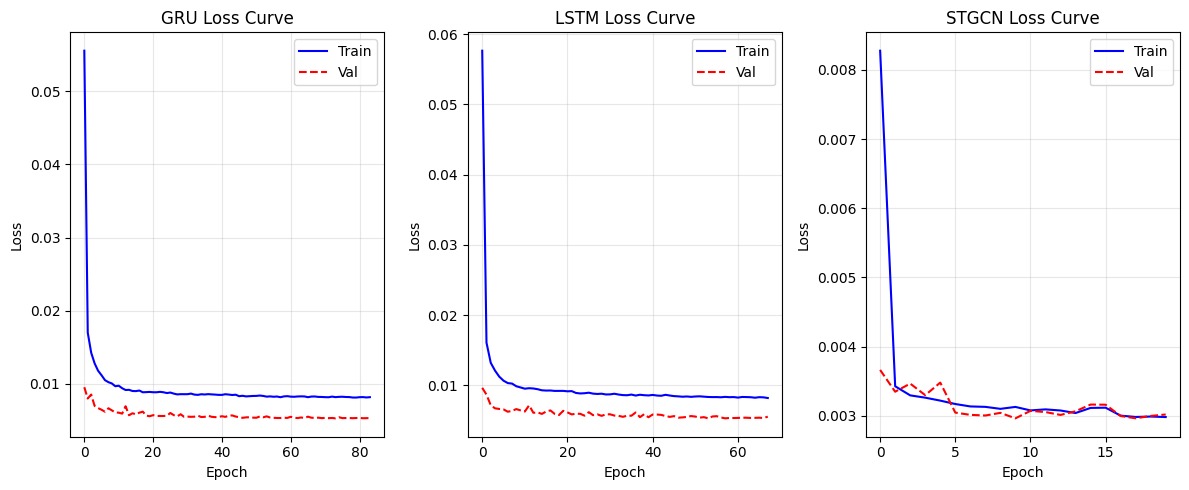

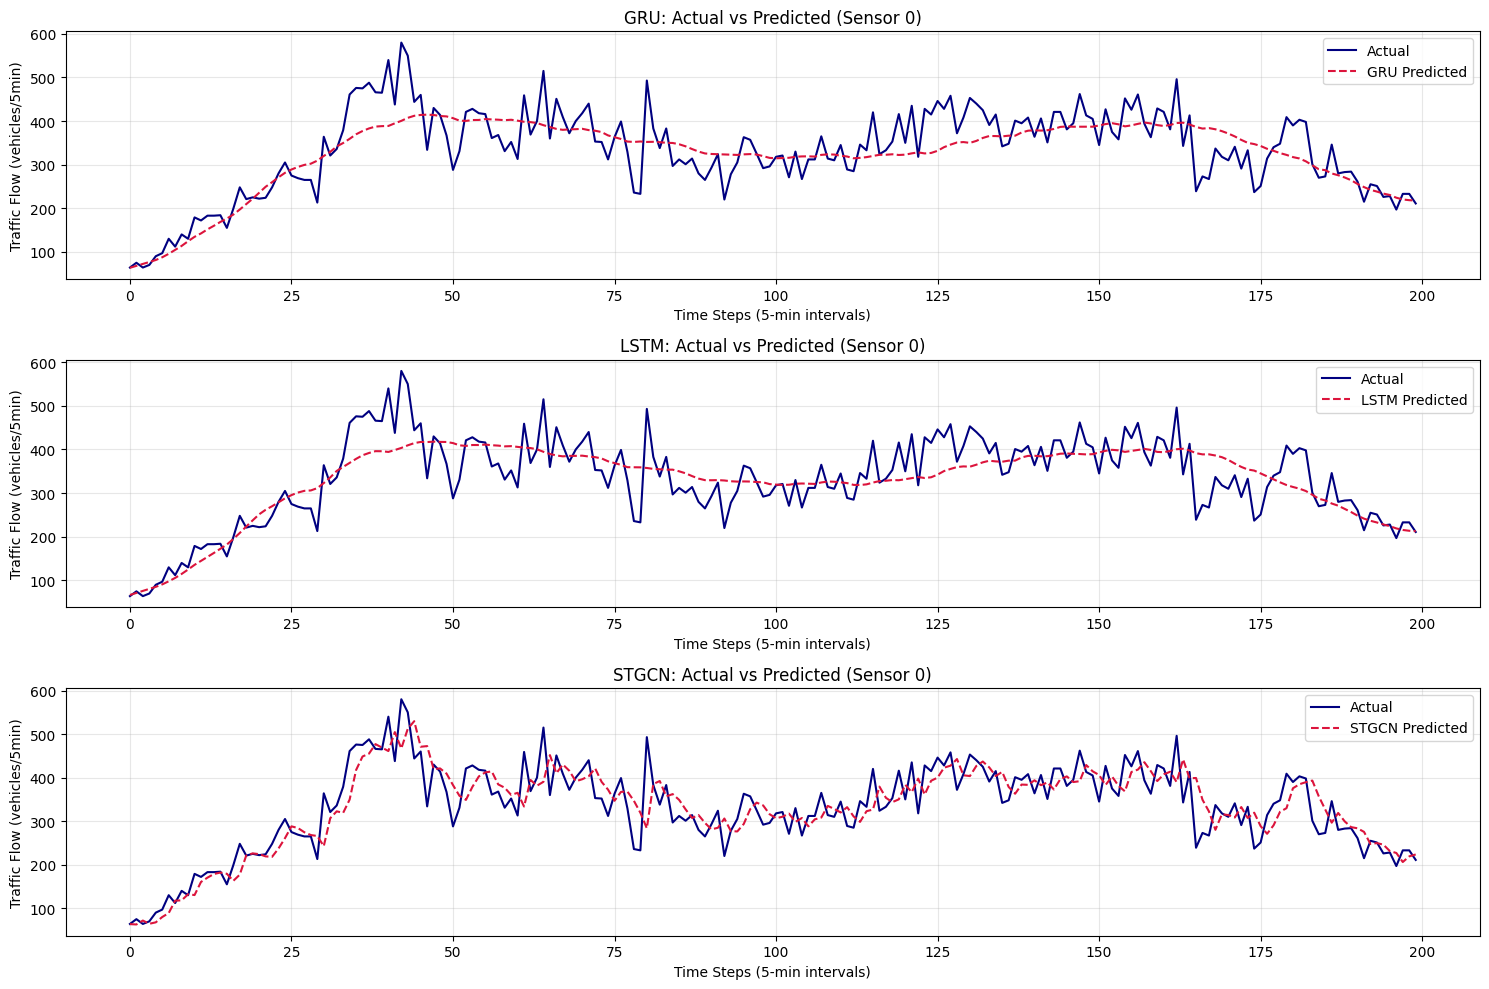

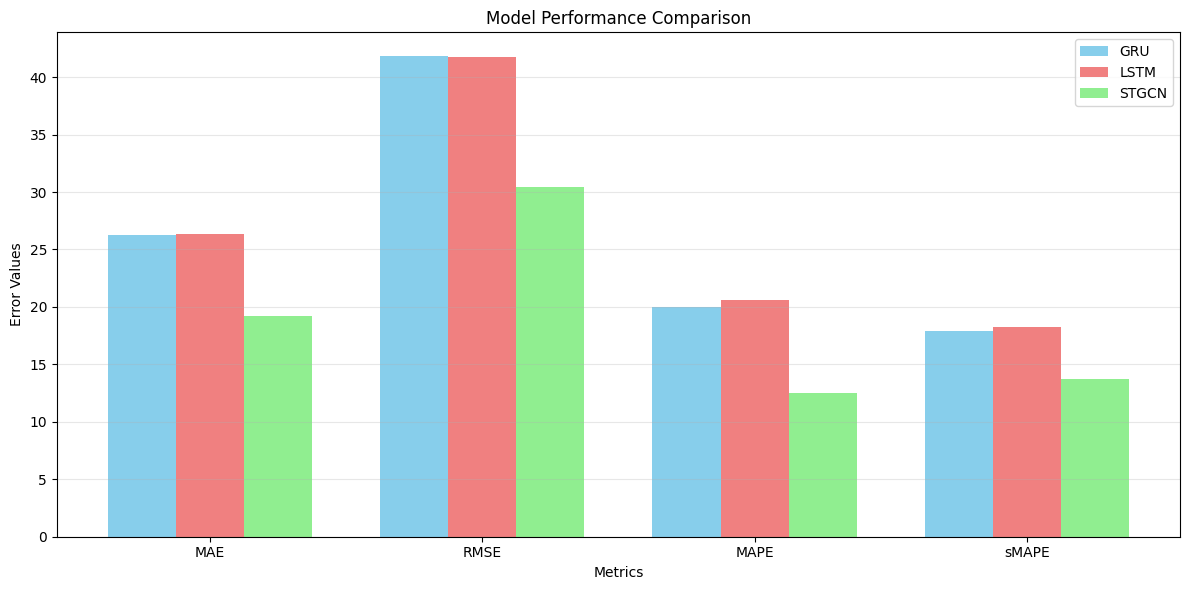

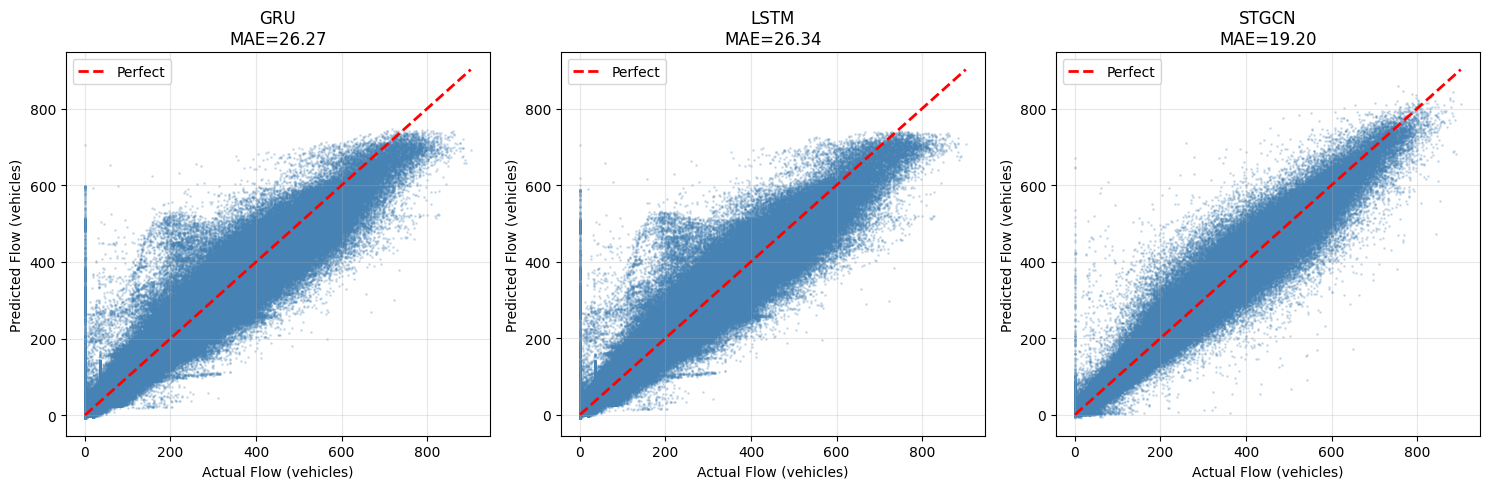

In [10]:
print("\n" + "="*60)
print("STEP 5: Generating Visualizations")
print("="*60)

# Create directory for figures
os.makedirs('figures', exist_ok=True)

# 8.1 Loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(gru_history['train_loss'], label='Train', color='blue')
plt.plot(gru_history['val_loss'], label='Val', color='red', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(lstm_history['train_loss'], label='Train', color='blue')
plt.plot(lstm_history['val_loss'], label='Val', color='red', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(stgcn_history['train_loss'], label='Train', color='blue')
plt.plot(stgcn_history['val_loss'], label='Val', color='red', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('STGCN Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 8.2 Predictions comparison (first sensor, first 200 timesteps)
sensor_id = 0
n_steps = 200

plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(gru_true[:n_steps, sensor_id], label='Actual', color='navy', linewidth=1.5)
plt.plot(gru_preds[:n_steps, sensor_id], label='GRU Predicted', color='crimson', linestyle='--', linewidth=1.5)
plt.xlabel('Time Steps (5-min intervals)')
plt.ylabel('Traffic Flow (vehicles/5min)')
plt.title(f'GRU: Actual vs Predicted (Sensor {sensor_id})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(lstm_true[:n_steps, sensor_id], label='Actual', color='navy', linewidth=1.5)
plt.plot(lstm_preds[:n_steps, sensor_id], label='LSTM Predicted', color='crimson', linestyle='--', linewidth=1.5)
plt.xlabel('Time Steps (5-min intervals)')
plt.ylabel('Traffic Flow (vehicles/5min)')
plt.title(f'LSTM: Actual vs Predicted (Sensor {sensor_id})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(stgcn_true[:n_steps, sensor_id], label='Actual', color='navy', linewidth=1.5)
plt.plot(stgcn_preds[:n_steps, sensor_id], label='STGCN Predicted', color='crimson', linestyle='--', linewidth=1.5)
plt.xlabel('Time Steps (5-min intervals)')
plt.ylabel('Traffic Flow (vehicles/5min)')
plt.title(f'STGCN: Actual vs Predicted (Sensor {sensor_id})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 8.3 Bar chart comparison
metrics_names = ['MAE', 'RMSE', 'MAPE', 'sMAPE']
gru_values = [gru_metrics[m] for m in metrics_names]
lstm_values = [lstm_metrics[m] for m in metrics_names]
stgcn_values = [stgcn_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, gru_values, width, label='GRU', color='skyblue')
plt.bar(x, lstm_values, width, label='LSTM', color='lightcoral')
plt.bar(x + width, stgcn_values, width, label='STGCN', color='lightgreen')

plt.xlabel('Metrics')
plt.ylabel('Error Values')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics_names)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 8.4 Scatter plots comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_data = [
    (gru_true.flatten(), gru_preds.flatten(), 'GRU', axes[0]),
    (lstm_true.flatten(), lstm_preds.flatten(), 'LSTM', axes[1]),
    (stgcn_true.flatten(), stgcn_preds.flatten(), 'STGCN', axes[2])
]

for true, pred, name, ax in models_data:
    ax.scatter(true, pred, alpha=0.2, s=1, c='steelblue')
    ax.plot([true.min(), true.max()], [true.min(), true.max()], 'r--', linewidth=2, label='Perfect')
    ax.set_xlabel('Actual Flow (vehicles)')
    ax.set_ylabel('Predicted Flow (vehicles)')
    ax.set_title(f'{name}\nMAE={np.mean(np.abs(true - pred)):.2f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/scatter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# PART 9: SAVE RESULTS


In [11]:
print("\n" + "="*60)
print("STEP 6: Saving Results")
print("="*60)

# Save metrics to JSON
results = {
    'GRU': {k: float(v) for k, v in gru_metrics.items()},
    'LSTM': {k: float(v) for k, v in lstm_metrics.items()},
    'STGCN': {k: float(v) for k, v in stgcn_metrics.items()}
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("✅ Results saved to 'results.json'")

# Save models
torch.save(gru_model.state_dict(), 'best_gru.pth')
torch.save(lstm_model.state_dict(), 'best_lstm.pth')
torch.save(stgcn_model.state_dict(), 'best_stgcn.pth')
print("✅ Models saved to 'best_gru.pth', 'best_lstm.pth', 'best_stgcn.pth'")

# Save predictions for later use
np.save('gru_predictions.npy', gru_preds)
np.save('lstm_predictions.npy', lstm_preds)
np.save('stgcn_predictions.npy', stgcn_preds)
np.save('true_values.npy', stgcn_true)
print("✅ Predictions saved")

# Print final summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"GRU   - MAE: {gru_metrics['MAE']:.4f}, RMSE: {gru_metrics['RMSE']:.4f}, MAPE: {gru_metrics['MAPE']:.2f}%")
print(f"LSTM  - MAE: {lstm_metrics['MAE']:.4f}, RMSE: {lstm_metrics['RMSE']:.4f}, MAPE: {lstm_metrics['MAPE']:.2f}%")
print(f"STGCN - MAE: {stgcn_metrics['MAE']:.4f}, RMSE: {stgcn_metrics['RMSE']:.4f}, MAPE: {stgcn_metrics['MAPE']:.2f}%")
print("="*60)

print("\n✅ All done! Check 'figures/' folder for visualizations.")



STEP 6: Saving Results
✅ Results saved to 'results.json'
✅ Models saved to 'best_gru.pth', 'best_lstm.pth', 'best_stgcn.pth'
✅ Predictions saved

FINAL SUMMARY
GRU   - MAE: 26.2658, RMSE: 41.8056, MAPE: 19.95%
LSTM  - MAE: 26.3430, RMSE: 41.7482, MAPE: 20.60%
STGCN - MAE: 19.2047, RMSE: 30.4171, MAPE: 12.54%

✅ All done! Check 'figures/' folder for visualizations.
